In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torchvision
import pickle
import deepRD.tools.trajectoryTools as trajectoryTools
import deepRD.tools.analysisTools as analysisTools
import csv
import math
from deepRD.noiseSampler import noiseSampler
from torchvision.transforms import ToTensor
from torch import nn
from torch.utils.data import DataLoader
from sklearn.neighbors import KernelDensity
from sklearn.decomposition import PCA
from sklearn.preprocessing import RobustScaler
from scipy.stats import gaussian_kde, wasserstein_distance_nd

In [2]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
device

/srv/data/jakut77/miniconda3/envs/pyta/lib/python3.12/site-packages/torch/cuda/__init__.py:129: UserWarning: CUDA initialization: Unexpected error from cudaGetDeviceCount(). Did you run some cuda functions before calling NumCudaDevices() that might have already set an error? Error 804: forward compatibility was attempted on non supported HW (Triggered internally at /opt/conda/conda-bld/pytorch_1729647406761/work/c10/cuda/CUDAFunctions.cpp:108.)
  return torch._C._cuda_getDeviceCount() > 0


'cpu'

In [3]:
def apply_periodic(q, boxsize):
    """
    Apply periodic boundary conditions to positions q.

    q       : [..., 3] (torch.Tensor)
    boxsize : float or array-like of length 3
              box spans [-L/2, L/2] in each dimension
    """
    if not torch.is_tensor(q):
        q = torch.as_tensor(q, dtype=torch.float32)

    if not torch.is_tensor(boxsize):
        boxsize = torch.as_tensor(boxsize, dtype=q.dtype, device=q.device)

    if boxsize.ndim == 0:
        boxsize = boxsize.expand(3)

    # Map to [0, L), then shift back to [-L/2, L/2)
    q_shifted = q + boxsize / 2.0
    q_wrapped = torch.remainder(q_shifted, boxsize)
    q_periodic = q_wrapped - boxsize / 2.0
    return q_periodic


def bistable_force(q, minimaDist, kconstants, scale=1.0):
    """
    Vectorised bistable force for positions q.

    q         : [..., 3]  (any leading batch dims, torch.Tensor)
    minimaDist: float
    kconstants: (3,) array-like or tensor [kx, ky, kz]
    scale     : float

    Returns:
        force: [..., 3]
    """
    if not torch.is_tensor(q):
        q = torch.as_tensor(q, dtype=torch.float32)

    kx, ky, kz = kconstants
    x = q[..., 0]
    y = q[..., 1]
    z = q[..., 2]

    force = torch.zeros_like(q)
    force[..., 0] = - kx * 4 * x * (x**2 - minimaDist**2) / (minimaDist**4)
    force[..., 1] = - ky * 2 * y
    force[..., 2] = - kz * 2 * z

    return scale * force


def aboba_deterministic_step(q_n, v_n, dt_eff, Gamma, mass,
                             minimaDist, kconstants, boxsize, scale=1.0):
    """
    Deterministic ABOBA step (no noise) for one time step dt_eff.

    q_n, v_n : [..., 3]
    dt_eff   : float (effective dt = step * dt)
    Gamma    : friction scalar
    mass     : mass scalar
    """
    # A: first half-step in position
    q_half = q_n + v_n * (dt_eff / 2.0)
    #q_half = apply_periodic(q_half, boxsize)

    # Force at x^{n+1/2}
    F_half = bistable_force(q_half, minimaDist, kconstants, scale=scale)

    # BOB step without noise:
    # expterm = exp(-Gamma * dt / mass)
    # frictionForceTerm = v_n * expterm + (1 + expterm) * F * dt/(2m)
    expterm = torch.exp(torch.tensor(-Gamma * dt_eff / mass,
                                     dtype=q_n.dtype, device=q_n.device))

    v_det = v_n * expterm + (1.0 + expterm) * F_half * (dt_eff / (2.0 * mass))

    # A: second half-step in position
    q_next = q_half + v_det * (dt_eff / 2.0)
    q_next = apply_periodic(q_next, boxsize)

    return q_next, v_det

def compute_r_cg_from_fine(q, v, k, parameters,
                           boxsize=5.0, scale=1.0):
    """
    Compute coarse-grained interaction noise r_cg from fine benchmark trajectories,
    using the same ABOBA scheme as langevinNoiseSampler but *without* noise.

    q, v : [n_traj, T, 3]  (fine dt)
    dt   : fine timestep
    k : integer k (dt_eff = k * dt)

    Gamma, mass       : friction and mass
    minimaDist        : bistable parameter
    kconstants        : (3,) for bistable (kx, ky, kz)
    boxsize           : scalar or (3,) – periodic box, interval [-L/2, L/2]
    scale             : scale factor for the potential

    Returns:
        q_next, v_next, r_next  : [n_traj, T-step, 3]

            v_next = v_det(q_n, v_n; dt_eff) + r_next
    """
    assert q.shape == v.shape
    assert q.ndim == 3 and q.shape[-1] == 3, "q, v must be [n_traj, T, 3]"
    assert k >= 1
    
    dt = parameters['dt']
    Gamma = parameters['Gamma']
    mass = parameters['mass']

    n_traj, T, _ = q.shape
    
    T_cg = T - k
    if T_cg <= 0:
        raise ValueError(f"Not enough timesteps T={T} for step={k}.")

    dt_eff = k * dt

    # fine start states for every jump
    q_start    = q[:, :T_cg, :]    # [n_traj, T-step, 3]
    v_start    = v[:, :T_cg, :]    # [n_traj, T-step, 3]

    # --- fine end velocities for each jump ---
    v_end = v[:, k:, :]                # v_{n+k}


    # deterministic ABOBA step with dt_eff
    _, v_det_end = aboba_deterministic_step(
        q_start, v_start,
        dt_eff=dt_eff,
        Gamma=Gamma,
        mass=mass,
        minimaDist=minimaDist,
        kconstants=kconstants,
        boxsize=boxsize,
        scale=scale,
    )

    # noise that produces the END velocity
    r_end = v_end - v_det_end          # r_{n+k} in end-aligned convention

    # --- now restrict to the coarse grid: n = 0, k, 2k, ... ---
    # end indices: k, 2k, 3k, ...
    q_eff = q[:, k::k, :]
    v_eff = v[:, k::k, :]
    
    # r_end[n] corresponds to jump from n -> n+k, i.e. lands on (n+k)
    # so pick start indices 0, k, 2k, ...
    r_eff = r_end[:, 0::k, :]

    # lengths match by construction
    assert q_eff.shape == v_eff.shape == r_eff.shape

    return q_eff, v_eff, r_eff

In [75]:
# System type: 'bistable', 'dimer'
systemType = 'bistable'

# datapoint = [time (1), qi (3), vi (3), ? (1), ri(3)] -- 11 dim for benchmark
# for dimer, alternating between particle 1 and particle 2.

#for generated trajs, 
# datapoint = [time (1), qi (3), vi (3), ri(3)] - 10 dim

# Datasets directory
localDirectoryBase = "/group/ag_cmb/scratch/maojrs/stochasticClosure/" + systemType + "/boxsize5/"

# loading multiple simulation folders for comparisons, and corresponding labels

# Conditioning variables: piri, piririm, pipimri, etc. - for dimer, piridqi
datasetFolders = ["benchmark/", "benchmark_half_dt/"]#, "benchmarkReducedGen4_piririm/"]
datasetLabels = ["benchmark", "half dt bench"]#, "piririm_2, Tr=0.6"]
nModels = len(datasetFolders)

nTrajs = 100 # no. of trajectories to load per data folder

nTimestepsBench = 10000 # length of benchmark trajectory
datapointDim = 10 # dimensionality of datapoints.
numFilesBench = 2500

# Loading Benchmark data

benchDataset = torch.empty((nTrajs, nTimestepsBench, datapointDim))

fileIDS = np.sort(np.random.choice(numFilesBench, nTrajs, replace=False))

benchFileDirectory = localDirectoryBase + "benchmark/simMoriZwanzig_"

for j, fnum in enumerate(fileIDS):
    try:
        ds = torch.Tensor(trajectoryTools.loadTrajectory(benchFileDirectory, fnum))
    except FileNotFoundError:
        print(f'File {fnum} not available')
        continue

    # cutting out meaningless variable
    if ds.shape[1]==11:
        ds = torch.cat((ds[:, :7], ds[:, -3:]), dim=1)
    
    benchDataset[j] = ds


# Loading Benchmark data for doubled timestep

halfDataset = torch.empty((nTrajs, nTimestepsBench*2, datapointDim))

fileIDS = np.sort(np.random.choice(numFilesBench, nTrajs, replace=False))

halfFileDirectory = localDirectoryBase + "benchmark_half_dt/simMoriZwanzig_"

for j, fnum in enumerate(fileIDS):
    try:
        ds = torch.Tensor(trajectoryTools.loadTrajectory(halfFileDirectory, fnum))
    except FileNotFoundError:
        print(f'File {fnum} not available')
        continue

    # cutting out meaningless variable
    if ds.shape[1]==11:
        ds = torch.cat((ds[:, :7], ds[:, -3:]), dim=1)
    
    halfDataset[j] = ds

In [76]:
#dataset_norm = (dataset[0] - mean_d)/std_d
benchDataset.shape, halfDataset.shape # nModels, nTrajs, nTimesteps, datapointDims

(torch.Size([100, 10000, 10]), torch.Size([100, 20000, 10]))

In [77]:
b_timesteps = benchDataset[:, :, 0]
b_qT = benchDataset[:, :, 1:4]
b_rT = benchDataset[:, :, -3:]
b_vT = benchDataset[:, :, 4:7]
b_rNxtT = torch.roll(b_rT, -1, 1)

In [101]:
h_timesteps = halfDataset[:, 2::2, 0]
h_qT = halfDataset[:, 2::2, 1:4]
h_rT = halfDataset[:, 2::2, -3:]
h_vT = halfDataset[:, 2::2, 4:7]

h_rNxtT = torch.roll(h_rT, -1, 1)

In [102]:
# COARSE-GRAINING
step = 2

q = halfDataset[..., 1:4]  # position (not used now, but may be later)
v = halfDataset[..., 4:7]   # velocity
r = halfDataset[..., 8:11]  # auxiliary var

# Load parameters from parameters file
parameterDictionary = analysisTools.readParameters(localDirectoryBase + "benchmark_half_dt/parameters")

# Parameters for external potential (will only acts on distinguished particles (type 1))
minimaDist = 1.5
kconstants = np.array([1.0, 1.0, 1.0])
scalefactor = 1

cg_qT, cg_vT, cg_rT = compute_r_cg_from_fine(
            q, v,
            k=step,
            parameters=parameterDictionary
        )

In [103]:
b_vT.shape, h_vT.shape, cg_vT.shape

(torch.Size([100, 10000, 3]),
 torch.Size([100, 9999, 3]),
 torch.Size([100, 9999, 3]))

In [104]:
torch.mean(h_qT == cg_qT, dtype=float), torch.mean(h_vT == cg_vT, dtype=float), torch.mean(h_rT == cg_rT, dtype=float)

(tensor(1., dtype=torch.float64),
 tensor(1., dtype=torch.float64),
 tensor(0., dtype=torch.float64))

In [106]:
torch.allclose(h_rT, cg_rT)

False

In [105]:
print('Velocity')

print(f'Mean Bench: \t', torch.mean(b_vT, dim=(0,1)))
print('Std Bench: \t', torch.std(b_vT, dim=(0,1)), '\n')

print(f'Mean Half:\t', torch.mean(h_vT, dim=(0,1)))
print(f'Std Half:\t', torch.std(h_vT, dim=(0,1)), '\n')

print(f'Mean CG:\t', torch.mean(cg_vT, dim=(0,1)))
print('Std CG:\t', torch.std(cg_vT, dim=(0,1)), '\n')

    
print('\n Auxiliary Var')
print('Mean Bench: \t', torch.mean(b_rT, dim=(0,1)))
print('Std Bench: \t', torch.std(b_rT, dim=(0,1)), '\n')

print('Mean Half: \t', torch.mean(h_rT, dim=(0,1)))
print('Std Half: \t', torch.std(h_rT, dim=(0,1)), '\n')

print('Mean CG: \t', torch.mean(cg_rT, dim=(0,1)))
print('Std CG: \t', torch.std(cg_rT, dim=(0,1)), '\n')

Velocity
Mean Bench: 	 tensor([-0.0001, -0.0004, -0.0003])
Std Bench: 	 tensor([0.1418, 0.1418, 0.1434]) 

Mean Half:	 tensor([-3.9007e-04,  1.3148e-04, -4.6133e-05])
Std Half:	 tensor([0.1371, 0.1362, 0.1361]) 

Mean CG:	 tensor([-3.9007e-04,  1.3148e-04, -4.6133e-05])
Std CG:	 tensor([0.1371, 0.1362, 0.1361]) 


 Auxiliary Var
Mean Bench: 	 tensor([-1.9022e-05, -2.7118e-05, -4.5326e-05])
Std Bench: 	 tensor([0.0162, 0.0162, 0.0162]) 

Mean Half: 	 tensor([ 7.3864e-06, -2.6159e-06,  1.0493e-05])
Std Half: 	 tensor([0.0078, 0.0078, 0.0077]) 

Mean CG: 	 tensor([ 1.8384e-05, -4.1861e-06,  2.4116e-05])
Std CG: 	 tensor([0.0151, 0.0150, 0.0150]) 



In [72]:
colors = ["tab:red", "tab:blue", "tab:green", "tab:orange", "tab:purple"]

def plot_pos_vel_distributions(b_qT, b_vT, qT, vT, model_labels=None, n_samples=50000):
    """
    Plots position and velocity marginal distributions for benchmark and reduced models.

    Args:
        b_qT : tensor [n_traj, n_steps, 3] -- benchmark positions
        b_vT : tensor [n_traj, n_steps, 3] -- benchmark velocities
        qT   : tensor [n_models, n_traj, n_steps, 3]
        vT   : tensor [n_models, n_traj, n_steps, 3]
        model_labels : list of str of length n_models (optional)
        n_samples : int -- number of random samples from each source
    """
    
    def sample_tensor(x, maxN):
        flat = x.reshape(-1, x.shape[-1])
        N = flat.shape[0]
        idx = np.random.choice(N, size=min(N, maxN), replace=False)
        return flat[idx].cpu().numpy()

    b_q_s = sample_tensor(b_qT, n_samples)   # [N, 3]
    b_v_s = sample_tensor(b_vT, n_samples)

    q_s = sample_tensor(qT, n_samples)   # [N, 3]
    v_s = sample_tensor(vT, n_samples)

    # -------------------------------------------------------
    # 3. Plotting
    # -------------------------------------------------------
    fig, axes = plt.subplots(2, 3, figsize=(15, 8))
    dims = ["x", "y", "z"]

    # --------------------------
    # Position distributions
    # --------------------------
    for d in range(3):
        ax = axes[0, d]

        # Benchmark KDE
        kde_b = gaussian_kde(b_q_s[:, d])
        xs = np.linspace(b_q_s[:, d].min(), b_q_s[:, d].max(), 400)
        ax.plot(xs, kde_b(xs), color="black", lw=2, label="Benchmark")

        # Double KDE
        kde_d = gaussian_kde(q_s[:, d])
        ax.plot(xs, kde_d(xs), color="red", lw=1.5, label="half")

        ax.set_title(f"Position distribution: {dims[d]}")
        ax.set_xlabel(f"q_{dims[d]}")
        ax.set_ylabel("Density")

    # --------------------------
    # Velocity distributions
    # --------------------------
    for d in range(3):
        ax = axes[1, d]

        # Benchmark KDE
        kde_b = gaussian_kde(b_v_s[:, d])
        xs = np.linspace(b_v_s[:, d].min(), b_v_s[:, d].max(), 400)
        ax.plot(xs, kde_b(xs), color="black", lw=2, label="Benchmark")

        # Double KDE
        kde_d = gaussian_kde(v_s[:, d])
        ax.plot(xs, kde_d(xs), color="red", lw=1.5, label="half")

        ax.set_title(f"Velocity distribution: {dims[d]}")
        ax.set_xlabel(f"v_{dims[d]}")
        ax.set_ylabel("Density")

    # --------------------------
    # Final formatting
    # --------------------------
    handles, labels = axes[0,0].get_legend_handles_labels()
    fig.legend(handles, labels, loc="upper right", fontsize=12)
    plt.tight_layout()
    plt.show()

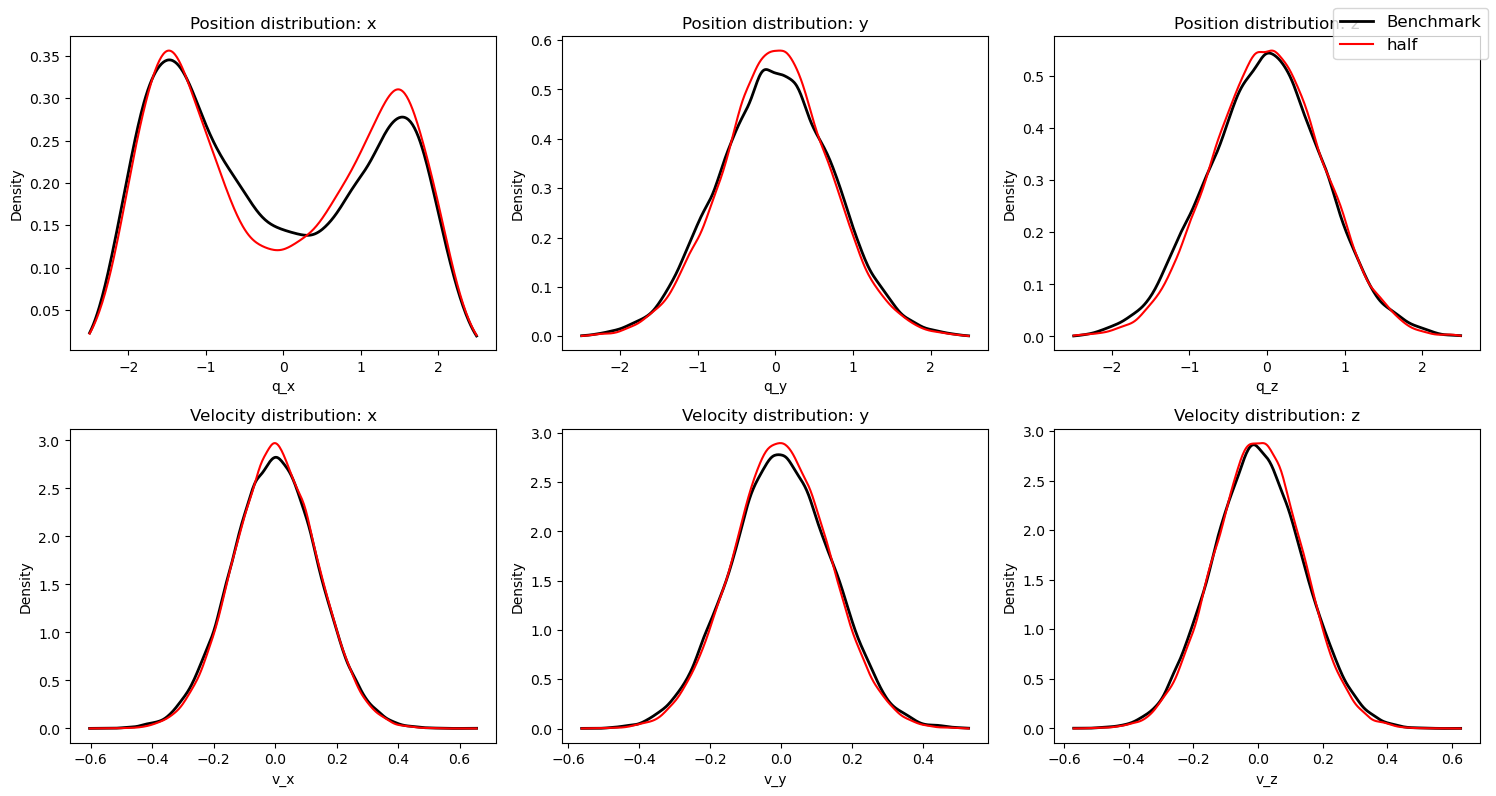

In [73]:
plot_pos_vel_distributions(b_qT, b_vT, d_qT, d_vT)

In [38]:
def correlation_fft(a, b, trunc):
    """Calculates correlation via FFT."""
    len_a = len(a)
    a = np.concatenate([a, np.zeros(len_a)])
    b = np.concatenate([b, np.zeros(len_a)])
    a_fft = np.fft.fft(a)
    b_fft = np.fft.fft(b)
    corr = np.fft.ifft(a_fft * np.conj(b_fft))
    corr = corr[:trunc].real
    corr /= np.linspace(len_a, len_a - trunc + 1, trunc)
    return corr

In [39]:
# CALCULATING AUTOCORRELATION FUNCTIONS.
stride = 2
lagtimesteps = 2000//stride
mTrajs = 20
t_lags = np.arange(lagtimesteps)*0.05*stride

# ACF by FFT for 1-D traj, then summing up over vector dimensions and all trajs 
ACF_FFT = np.zeros((1+nModels, 2, lagtimesteps))
    
for trajInd in np.random.choice(nTrajs, mTrajs):
    
    #print('Benchmark')
    # position
    ACF_FFT[0, 0] += np.sum([correlation_fft(b_qT[trajInd, :, i], b_qT[trajInd, :, i], lagtimesteps) for i in range(b_qT.shape[2])], axis=0)
    # velocity
    ACF_FFT[0, 1] += np.sum([correlation_fft(b_vT[trajInd, :, i], b_vT[trajInd, :, i], lagtimesteps) for i in range(b_vT.shape[2])], axis=0)

    #print('Double')
    # position
    ACF_FFT[1, 0] += np.sum([correlation_fft(d_qT[trajInd, :, i], d_qT[trajInd, :, i], lagtimesteps) for i in range(d_qT.shape[2])], axis=0)
    # velocity
    ACF_FFT[1, 1] += np.sum([correlation_fft(d_vT[trajInd, :, i], d_vT[trajInd, :, i], lagtimesteps) for i in range(d_vT.shape[2])], axis=0)
    

ACF_FFT[0, 0] /= ACF_FFT[0, 0, 0]
ACF_FFT[0, 1] /= ACF_FFT[0, 1, 0]
ACF_FFT[1, 0] /= ACF_FFT[1, 0, 0]
ACF_FFT[1, 1] /= ACF_FFT[1, 1, 0]

In [40]:
def plot_acf_results(ACF_FFT, t_lags):
    """
    Plot distance (position) ACF and velocity ACF for benchmark + reduced models.

    ACF_FFT: array of shape [1 + nModels, 2, lag]
        [:, 0, :] → position ACF
        [:, 1, :] → velocity ACF
    t_lags: time axis in physical units
    labels: list of labels, length 1 + nModels
    """
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    labels = ['benchmark', 'half']

    # --------------------------
    # Position ACF (left panel)
    # --------------------------
    ax = axes[0]
    for i in range(2):
        ax.plot(
            t_lags, 
            ACF_FFT[i, 0], 
            label=labels[i], 
            lw=2 if i == 0 else 1.5,
            linestyle='-' if i == 0 else '--'
        )
    ax.set_title("Position ACF", fontsize=14)
    ax.set_xlabel("time (ns)", fontsize=12)
    ax.set_ylabel("ACF", fontsize=12)
    ax.legend()
    ax.grid(alpha=0.3)

    # --------------------------
    # Velocity ACF (right panel)
    # --------------------------
    ax = axes[1]
    for i in range(2):
        ax.plot(
            t_lags, 
            ACF_FFT[i, 1], 
            label=labels[i],
            lw=2 if i == 0 else 1.5,
            linestyle='-' if i == 0 else '--'
        )
    ax.set_title("Velocity ACF", fontsize=14)
    ax.set_xlabel("time (ns)", fontsize=12)
    ax.set_ylabel("ACF", fontsize=12)
    ax.grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

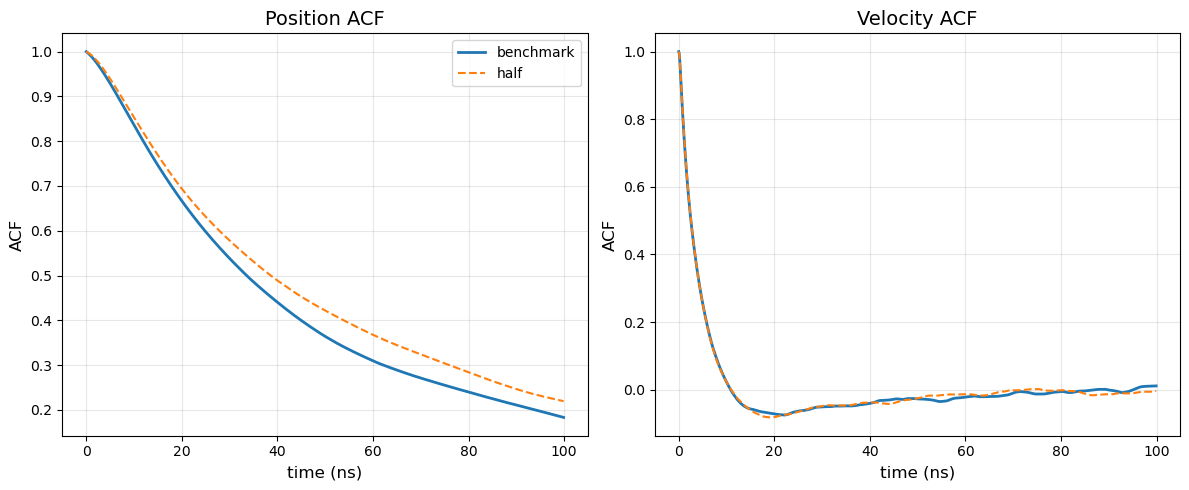

In [41]:
plot_acf_results(ACF_FFT, t_lags)